# Analisis exploratorio de los datos

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_tibaitata = pd.read_pickle("./Datasets/TibaitataLimpio.pkl")

## Caracterizacion del dataset

In [4]:


df = df_tibaitata.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# --- Métricas generales del dataset ---
n_registros = len(df)
periodo_inicio = df['Fecha'].min()
periodo_fin = df['Fecha'].max()
dias_totales = (periodo_fin - periodo_inicio).days + 1
n_estaciones = df['CodigoEstacion'].nunique()
n_parametros = df['Parametro'].nunique()

# Frecuencia temporal: diferencia más común entre fechas consecutivas únicas
fechas_unicas = df['Fecha'].drop_duplicates().sort_values()
frecuencia_detectada = fechas_unicas.diff().mode()[0]

print("=== Resumen general del dataset ===")
print(f"Número de registros:       {n_registros}")
print(f"Periodo cubierto:          {periodo_inicio.date()} a {periodo_fin.date()} ({dias_totales} días)")
print(f"Frecuencia temporal:       {frecuencia_detectada}")
print(f"Número de estaciones:      {n_estaciones}")
print(f"Número de parámetros:      {n_parametros}")

# --- Tabla resumen por variable (Parametro) ---
resumen_variables = df.groupby('Parametro').agg(
    n_registros=('Valor', 'size'),
    n_validos=('Valor', 'count'),   # cuenta no-nulos
    n_nulos=('Valor', lambda x: x.isna().sum()),
    fecha_inicio=('Fecha', 'min'),
    fecha_fin=('Fecha', 'max'),
    n_estaciones=('CodigoEstacion', 'nunique'),
    unidad=('Unidad', lambda x: x.dropna().unique()[0] if x.dropna().nunique() > 0 else None)
).reset_index()

resumen_variables['dias_cubiertos'] = (
    (resumen_variables['fecha_fin'] - resumen_variables['fecha_inicio']).dt.days + 1
)
resumen_variables['pct_completitud'] = (
    resumen_variables['n_validos'] / resumen_variables['n_registros'] * 100
).round(2)

print("\n=== Tabla resumen de variables ===")
display(resumen_variables)

=== Resumen general del dataset ===
Número de registros:       14545
Periodo cubierto:          2005-02-02 a 2022-10-31 (6481 días)
Frecuencia temporal:       1 days 00:00:00
Número de estaciones:      2
Número de parámetros:      5

=== Tabla resumen de variables ===


,Parametro,n_registros,n_validos,n_nulos,fecha_inicio,fecha_fin,n_estaciones,unidad,dias_cubiertos,pct_completitud
0,Humedad relativa del aire a 2 metros media diaria,2909,2909,0,2005-02-02,2022-10-31,1,%,6481,100.0
1,Radiación solar global horaria VALIDADA,2909,2909,0,2005-02-02,2022-10-31,1,Wh/m^2,6481,100.0
2,Temperatura máxima diaria,2909,2909,0,2005-02-02,2022-10-31,1,degC,6481,100.0
3,Temperatura mínima diaria,2909,2909,0,2005-02-02,2022-10-31,1,degC,6481,100.0
4,Velocidad 10 minutal del viento media diaria,2909,2909,0,2005-02-02,2022-10-31,1,m/s,6481,100.0


## Estadistica descriptiva

=== Estadística descriptiva por variable ===


,Parametro,n_datos,media,mediana,desviacion_std,minimo,maximo,p25,p50,p75,coef_variacion_%
0,Humedad relativa del aire a 2 metros media diaria,2909,81.744,82.125,5.552,12.929,97.295,78.094,82.125,85.688,6.791
1,Radiación solar global horaria VALIDADA,2909,4156.220,4054.500,1241.474,233.000,7461.600,3240.000,4054.500,5033.100,29.870
2,Temperatura máxima diaria,2909,20.208,20.000,1.432,14.400,25.200,19.400,20.000,21.000,7.084
3,Temperatura mínima diaria,2909,7.420,7.800,2.710,-3.600,13.200,5.600,7.800,9.600,36.523
4,Velocidad 10 minutal del viento media diaria,2909,1.904,1.849,0.641,0.763,19.919,1.597,1.849,2.119,33.661


/tmp/ipykernel_46797/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


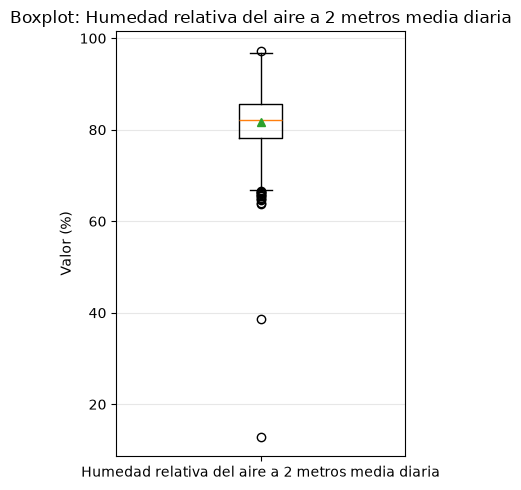

/tmp/ipykernel_46797/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


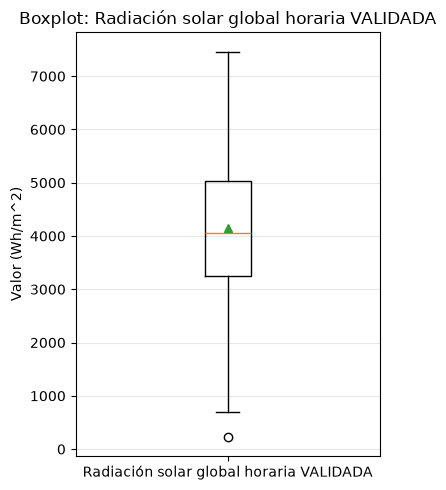

/tmp/ipykernel_46797/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


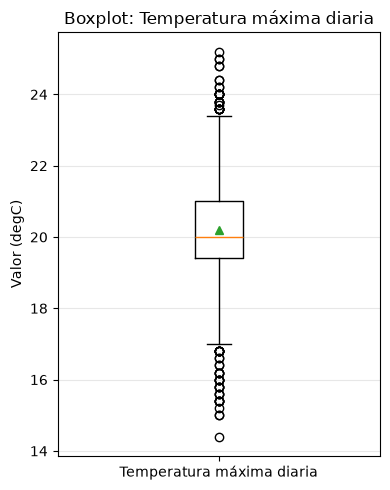

/tmp/ipykernel_46797/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


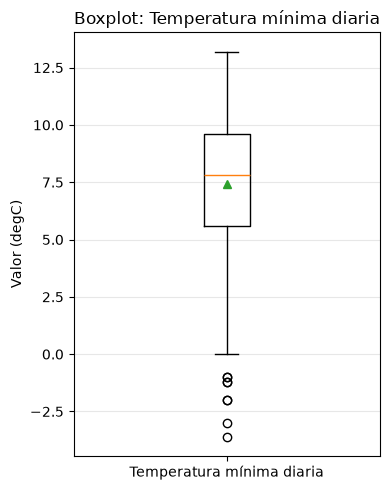

/tmp/ipykernel_46797/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


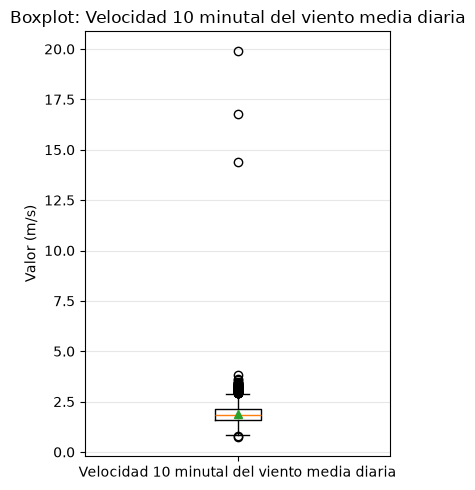

In [7]:
df = df_tibaitata.copy()

# --- Estadísticas descriptivas por variable (Parametro) ---
def coef_variacion(x):
    media = x.mean()
    return (x.std() / media * 100) if media != 0 else np.nan

estadisticas = df.groupby('Parametro')['Valor'].agg(
    n_datos='count',
    media='mean',
    mediana='median',
    desviacion_std='std',
    minimo='min',
    maximo='max',
    p25=lambda x: x.quantile(0.25),
    p50=lambda x: x.quantile(0.50),
    p75=lambda x: x.quantile(0.75),
).reset_index()

estadisticas['coef_variacion_%'] = df.groupby('Parametro')['Valor'].apply(coef_variacion).values
estadisticas = estadisticas.round(3)

print("=== Estadística descriptiva por variable ===")
display(estadisticas)

# --- Boxplot por cada variable (uno por figura, con su propia escala) ---
parametros = df['Parametro'].dropna().unique()

for param in parametros:
    datos = df.loc[df['Parametro'] == param, 'Valor'].dropna()
    unidad = df.loc[df['Parametro'] == param, 'Unidad'].dropna()
    unidad = unidad.iloc[0] if len(unidad) > 0 else ''

    plt.figure(figsize=(4, 5))
    plt.boxplot(datos, vert=True, showmeans=True)
    plt.title(f"Boxplot: {param}")
    plt.ylabel(f"Valor ({unidad})" if unidad else "Valor")
    plt.xticks([1], [param])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()